# Student Performance Analysis
## Objective
Analyze factors affecting student performance using the Students Performance dataset.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

## Loading the Dataset
We import the dataset and inspect its structure.

In [5]:
df=pd.read_csv("Data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Basic Exploratory Data Analysis
We examine dataset shape, columns, and summary statistics.

In [30]:
# Data Description
df.shape
df.info()
df.describe()
df.columns
# Any null Values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Key Insights

1. Female students perform better in reading and writing.
2. Male students perform slightly better in math.
3. Students who completed the test preparation course tend to score higher.
4. Math has the lowest average score among the three subjects.
5. Reading and writing scores show strong correlation.

In [ ]:
# Which subject has the highest average score?
df[["math score","reading score","writing score"]].mean()


In [ ]:
# What are the most common math scores?
df["math score"].value_counts().head()


In [31]:
# Do males or females score higher on average?
df.groupby("gender")[["math score","reading score","writing score"]].mean()


,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [ ]:
# Do students who completed test preparation perform better?
df.groupby("test preparation course")[["math score","reading score","writing score"]].mean()


In [ ]:
# Does parent education level affect student scores?
df.groupby("parental level of education")[["math score","reading score","writing score"]].mean()

## Data Visualization
We create visualizations to understand patterns in student performance.

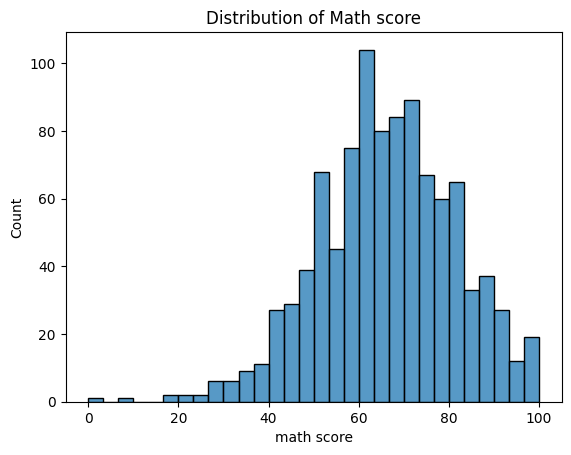

In [32]:
sns.histplot(df["math score"],bins=30)
plt.title("Distribution of Math score")
plt.show()

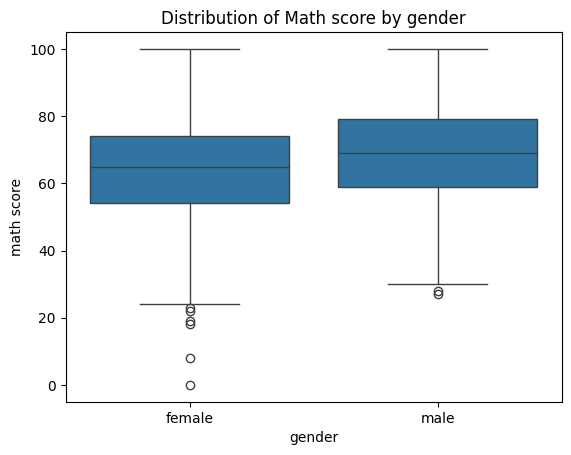

In [33]:
sns.boxplot(x='gender',y='math score',data=df)
plt.title("Distribution of Math score by gender")
plt.show()

<Axes: xlabel='writing score', ylabel='reading score'>

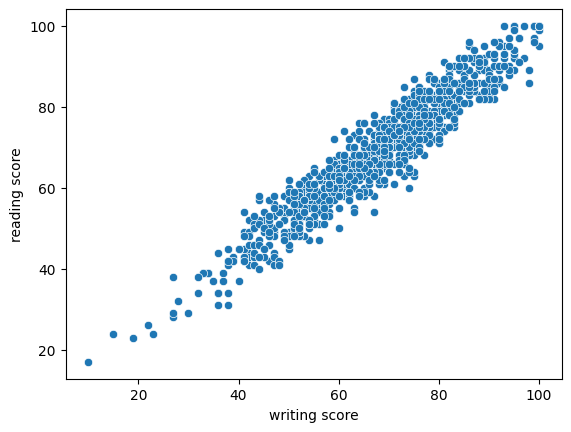

In [34]:
sns.scatterplot(x='writing score',y='reading score',data=df)

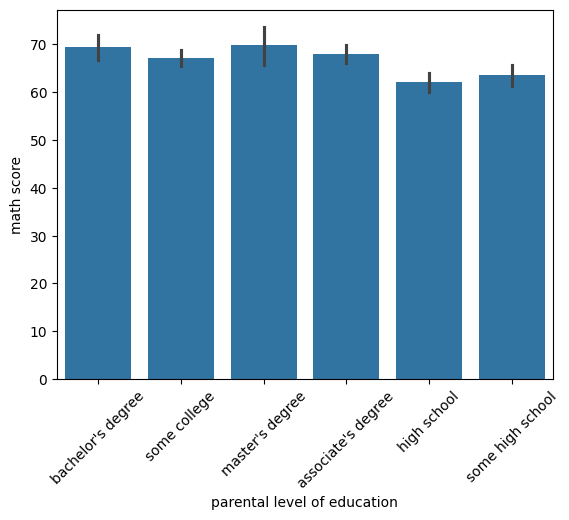

In [35]:
sns.barplot(x="parental level of education",y='math score',data=df)
plt.xticks(rotation=45)
plt.show()

In [36]:
corr=df[["math score","reading score","writing score"]].corr()
corr

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


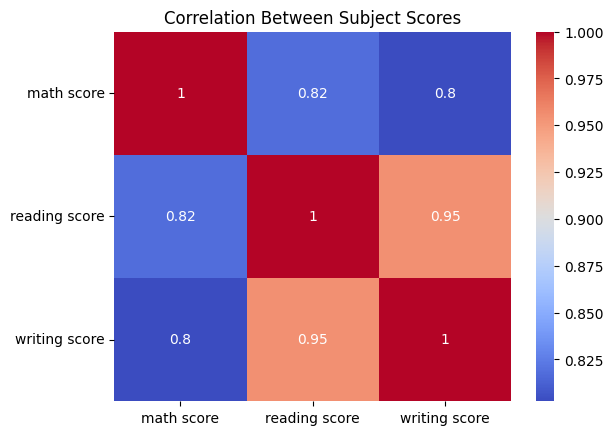

In [37]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Subject Scores")
plt.yticks(rotation=360)
plt.show()

In [11]:
x=df.drop('math score',axis=1)
y=df['math score']

In [42]:
x=pd.get_dummies(x,drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)

(800, 14)
(200, 14)


In [29]:
model = LinearRegression()
model.fit(x_train, y_train)
predictions = model.predict(x_test)
predictions[:10]

array([76.3879697 , 58.88597004, 76.99026483, 76.85180448, 87.62737816,
       79.0140238 , 64.65460865, 53.00791885, 74.18471015, 49.21353815])

In [22]:
mae = mean_absolute_error(y_test, predictions)
print(mae)

4.214763142474852


In [23]:
mse = mean_squared_error(y_test, predictions)
print(mse)

29.095169866715494
